In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import Feature_Engineering as FE
import matplotlib.pyplot as plt

In [8]:
data = FE.data
data_reg = data[(data['INGRESO'] == 1)]
y_reg = data_reg['logP47T']
excluir_cols = {'logP47T', 'Q','INGRESO', 'CODUSU', 'P47T', 'P21', 'T_VI', 'V12_M', 'V2_M', 'V3_M', 'V5_M', 'TOT_P12', 'PP08D1', 
                'logP21', 'logT_VI', 'logV12_M', 'logV2_M', 'logV3_M', 'logV5_M', 'logTOT_P12', 'logPP08D1','ANO4','TRIMESTRE'}
X_reg = data_reg.drop(columns=excluir_cols)

In [9]:
X_train_test, X_val, y_train_test, y_val = train_test_split(X_reg, y_reg, test_size=0.10, random_state=42) #Separo 10% para validacion
X_train, X_test, y_train, y_test = train_test_split(X_train_test, y_train_test, test_size=2/9, random_state=42) #Separo 20% total para test, 70% Train

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [10]:
# Grilla inicial hiperparámetros
param_grids_base = {
    "LinearRegression": {
        "reg__fit_intercept": [True, False]
    },
    "Ridge": {
        "reg__alpha": [2, 5, 10],
        "reg__fit_intercept": [True, False]
    },
    "Lasso": {
        "reg__alpha": [0.005,0.0025,0.0075],
        "reg__fit_intercept": [True, False]
    },
    "HistGradientBoostingRegressor": {
        "reg__max_iter": [100,200],
        "reg__learning_rate": [0.25, 0.1, 0.05],
        "reg__max_leaf_nodes": [200,400],
        "reg__min_samples_leaf": [15,30],
        "reg__l2_regularization": [0]
    }
}

In [11]:
# Preprocesadores

preproc_scaled = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder='drop')

preproc_unscaled = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder='drop')

In [12]:
#Pipelines

pipelines = {
        "LinearRegression": Pipeline([('preproc', preproc_unscaled), ('reg', LinearRegression())]),
        "Ridge": Pipeline([('preproc', preproc_scaled), ('reg', Ridge())]),
        "Lasso": Pipeline([('preproc', preproc_scaled), ('reg', Lasso(max_iter=200))]),
        "HistGradientBoostingRegressor": Pipeline([('preproc', preproc_unscaled), ('reg', HistGradientBoostingRegressor(random_state=42))])
    }

In [13]:
best_model = None
best_r2 = -np.inf
best_params = None

best_lr = None
best_lr_params = None
best_lr_r2 = -np.inf

best_ridge = None
best_ridge_params = None
best_ridge_r2 = -np.inf

best_lasso = None
best_lasso_params = None
best_lasso_r2 = -np.inf

best_hgb = None
best_hgb_params = None
best_hgb_r2 = -np.inf

for name, pipe in pipelines.items():
    print(f"\n=== Evaluando modelo: {name} ===")
    grid = GridSearchCV(
        pipe,
        param_grids_base[name],
        cv=5,
        refit='r2',
        scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'],
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train, y_train)

    best = grid.best_estimator_

    y_pred = best.predict(X_test)

    test_mse = mean_squared_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)

    # Guardar informacion de la mejor configuracion de cada modelo. Como en principio no sé cual es mejor entre los regresores lineales (estándar, Ridge, Lasso) ó el HistGradientBoosting, 
    # mantendré un registro de todos. Luego, solo usaré para graficar el mejor regresor lineal (incluyendo modelos con penalizacion como Ridge y Lasso), y el mejor HistGradientBoosting.

    if name == "LinearRegression":
        if test_r2 > best_lr_r2:
            best_lr = best
            best_lr_params = grid.best_params_
            best_lr_r2 = test_r2
    if name == "Ridge":
        if test_r2 > best_ridge_r2:
            best_ridge = best
            best_ridge_params = grid.best_params_
            best_ridge_r2 = test_r2
    if name == "Lasso":
        if test_r2 > best_lasso_r2:
            best_lasso = best
            best_lasso_params = grid.best_params_
            best_lasso_r2 = test_r2
    if name == "HistGradientBoostingRegressor":
        if test_r2 > best_hgb_r2:
            best_hgb = best
            best_hgb_params = grid.best_params_
            best_hgb_r2 = test_r2

    print("Best params:", grid.best_params_)
    print("Best CV score:", grid.best_score_)
    print("Regression metrics (test):")
    print("MSE:", test_mse)
    print("R2:", test_r2)

    if test_r2 > best_r2:
        best_r2 = test_r2
        best_model = best
        best_params = grid.best_params_

print("\n=== Mejor modelo global ===")
print("Mejor modelo:", best_model)
print("Mejores hiperparámetros:", best_params)
print("Mejor R2 en test:", best_r2)


=== Evaluando modelo: LinearRegression ===
Best params: {'reg__fit_intercept': False}
Best CV score: 0.5378532545895156
Regression metrics (test):
MSE: 0.06519544505050022
R2: 0.5442626315902053

=== Evaluando modelo: Ridge ===
Best params: {'reg__alpha': 5, 'reg__fit_intercept': True}
Best CV score: 0.5378606156027177
Regression metrics (test):
MSE: 0.06519684269134945
R2: 0.5442528616260287

=== Evaluando modelo: Lasso ===
Best params: {'reg__alpha': 0.0025, 'reg__fit_intercept': True}
Best CV score: 0.5169593848105813
Regression metrics (test):
MSE: 0.06823283570725144
R2: 0.523030282862958

=== Evaluando modelo: HistGradientBoostingRegressor ===


KeyboardInterrupt: 

In [ ]:
#Ahora quiero usar este mejor modelo global para, dados los datos de X_val, predecir y_val y registrar MSE y R2

y_val_pred = best_model.predict(X_val)
y_val_mse = mean_squared_error(y_val, y_val_pred)
y_val_r2 = r2_score(y_val, y_val_pred)

print("MSE en validación:", y_val_mse)
print("R2 en validación:", y_val_r2)

MSE en validación: 0.05109761789996068
R2 en validación: 0.6425289218668218


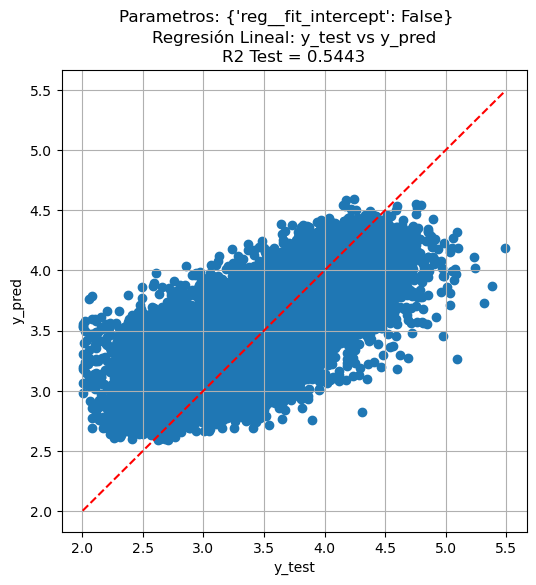

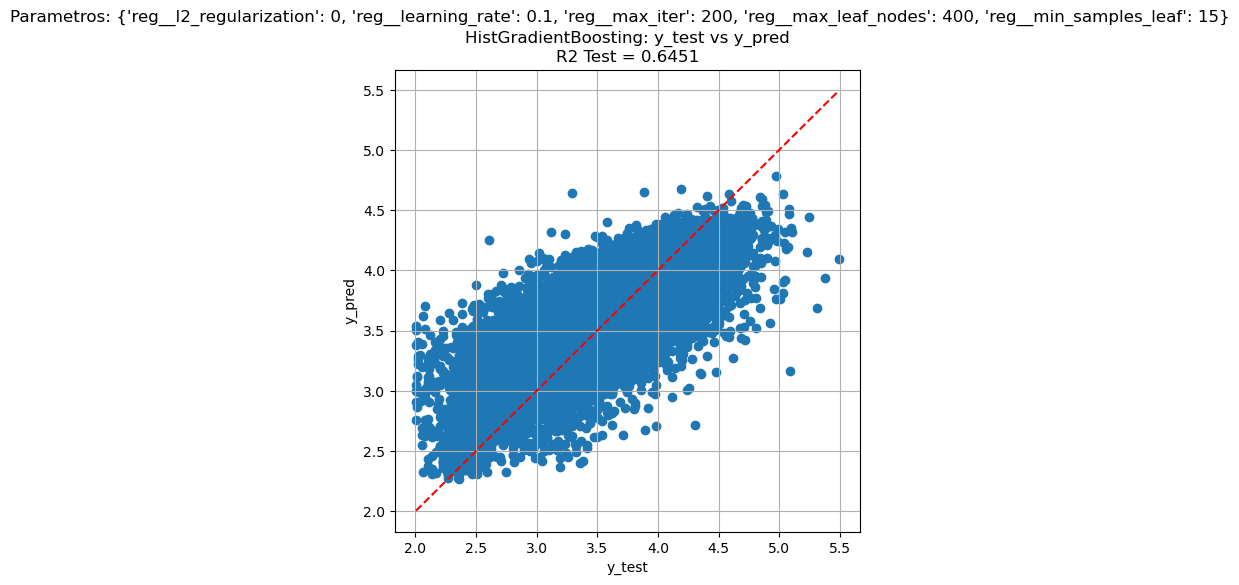

In [ ]:
# Como Ridge y Regresion Lineal son los que me dieron mejor en test, los grafico:
# Ridge

y_pred_lr = best_lr.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Regresión Lineal: y_test vs y_pred\nR2 Test = {:.4f}".format(best_lr_r2))
plt.suptitle("Parametros: {}".format(best_lr_params))
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.grid(True)
plt.savefig("Mejor_Regresion_Lineal.png")
plt.show()

# HGB
y_pred_hgb = best_hgb.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_hgb)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("HistGradientBoosting: y_test vs y_pred\nR2 Test = {:.4f}".format(best_hgb_r2))
plt.suptitle("Parametros: {}".format(best_hgb_params))
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.grid(True)
plt.savefig("Mejor_HGB.png")
plt.show()